In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def plot_precision_diagrams(yolo11, yolo26, yolov8=None, title: str = 'Plot'):
    """
    Combines and plots the training metrics of up to three models into
    a single diagram.

    @param yolo11, yolo26, yolov8: dataframes of up to three possible
    dataframes. df_model3 is optional
    @title: str -> The title for the plot
    """
    precision_1 = yolo11['metrics/precision(B)']
    precision_2 = yolo26['metrics/precision(B)']

    # displaying the 200 epochs can be dense, smooth the plots
    def smooth(y, w=15):
        return y.rolling(w, min_periods=1).mean()

    plt.plot(np.arange(0, yolo11.shape[0], 1), smooth(precision_1), label='Yolo11n')
    plt.plot(np.arange(0, yolo26.shape[0], 1), smooth(precision_2), label='Yolo26n')

    if yolov8 is not None:
        precision_3 = yolov8['metrics/precision(B)']
        plt.plot(
            np.arange(0, yolov8.shape[0], 1),
            smooth(precision_3),
            label='Yolov8n',
        )

    plt.xlabel('Epochs')
    plt.yticks(np.arange(0.0, 1.1, 0.1))
    plt.ylim(0.0, 1.0)
    plt.ylabel('metrics/precision(B)')
    plt.title(title)
    plt.legend()

    plt.savefig(title.replace(' ', '_').lower() + '.pdf')
    plt.show()

In [ ]:
tiled_yolo11_results = pd.read_csv(
    '../metrics/yolo/t/average/model_yolo11/yolo11_tiled_training_mean_results.csv'
).drop('Unnamed: 0', axis=1)
tiled_yolo26_results = pd.read_csv(
    '../metrics/yolo/t/average/model_yolo26/yolo26_tiled_training_mean_results.csv'
).drop('Unnamed: 0', axis=1)
tiled_yolo8_results = pd.read_csv(
    '../metrics/yolo/t/average/model_yolov8/yolov8_tiled_training_mean_results.csv'
).drop('Unnamed: 0', axis=1)

non_tiled_yolo11_results = pd.read_csv(
    '../metrics/yolo/nt/average/model_yolo11/yolo11_non_tiled_training_mean_results.csv'
).drop('Unnamed: 0', axis=1)
non_tiled_yolo26_results = pd.read_csv(
    '../metrics/yolo/nt/average/model_yolo26/yolo26_non_tiled_training_mean_results.csv'
).drop('Unnamed: 0', axis=1)
non_tiled_yolo8_results = pd.read_csv(
    '../metrics/yolo/nt/average/model_yolov8/yolov8_non_tiled_training_mean_results.csv'
).drop('Unnamed: 0', axis=1)


plot_precision_diagrams(
    tiled_yolo11_results,
    tiled_yolo26_results,
    tiled_yolo8_results,
    'Tiled-based Model Validation Precision',
)
plot_precision_diagrams(
    non_tiled_yolo11_results,
    non_tiled_yolo26_results,
    non_tiled_yolo8_results,
    'Non-Tiled-based Model Validation Precision',
)

FileNotFoundError: [Errno 2] No such file or directory: '../model_yolo11/yolo11_tiled_training_mean_results.csv'

In [ ]:
def plot_map50_diagrams(yolo11, yolo26, yolov8=None, title: str = 'Plot'):
    """
    Combines and plots the training metrics of up to three models into
    a single diagram.

    @param yolo11, yolo26, yolov8: dataframes of up to three possible
    dataframes. df_model3 is optional
    @title: str -> The title for the plot
    """
    precision_1 = yolo11['metrics/mAP50(B)']
    precision_2 = yolo26['metrics/mAP50(B)']

    # displaying the 200 epochs can be dense, smooth the plots
    def smooth(y, w=15):
        return y.rolling(w, min_periods=1).mean()

    plt.plot(np.arange(0, yolo11.shape[0], 1), smooth(precision_1), label='Yolo11n')
    plt.plot(np.arange(0, yolo26.shape[0], 1), smooth(precision_2), label='Yolo26n')

    if yolov8 is not None:
        precision_3 = yolov8['metrics/mAP50(B)']
        plt.plot(
            np.arange(0, yolov8.shape[0], 1),
            smooth(precision_3),
            label='Yolov8n',
        )

    plt.xlabel('Epochs')
    plt.yticks(np.arange(0.0, 1.1, 0.1))
    plt.ylim(0.0, 1.0)
    plt.ylabel('metrics/mAP50(B)')
    plt.title(title)
    plt.legend()

    plt.savefig(title.replace(' ', '_').lower() + '.pdf')
    plt.show()

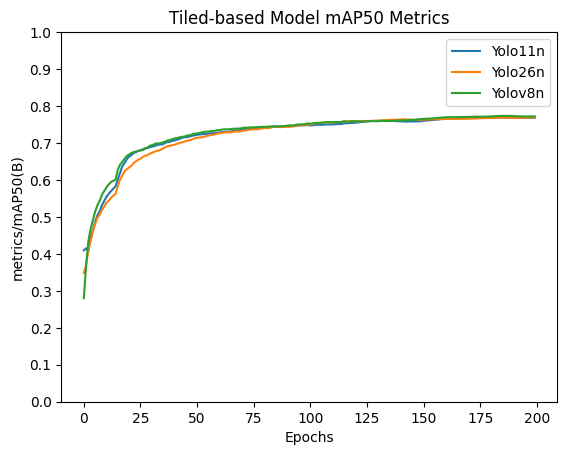

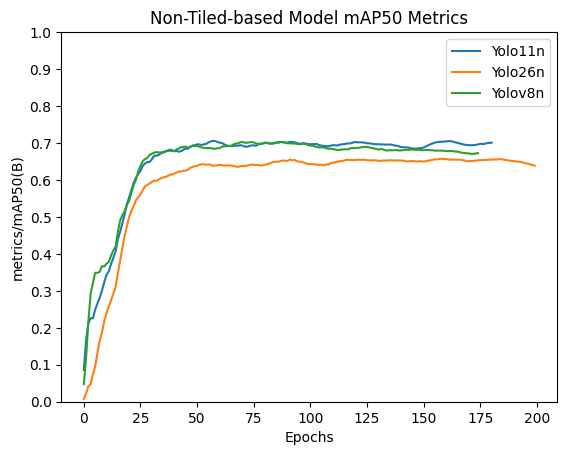

In [ ]:
plot_map50_diagrams(
    tiled_yolo11_results,
    tiled_yolo26_results,
    tiled_yolo8_results,
    'Tiled-based Model mAP50 Metrics',
)
plot_map50_diagrams(
    non_tiled_yolo11_results,
    non_tiled_yolo26_results,
    non_tiled_yolo8_results,
    'Non-Tiled-based Model mAP50 Metrics',
)